# 🛒 Sales & Retail Analytics
## Module 1: Data Cleaning & Feature Engineering

**Author:** Muhammad Umar Shahid  
**Email:** connect2umarshahid@gmail.com  
**GitHub:** github.com/Umar-Shahid  
**Dataset:** Global Superstore Sales (9,800 orders · 2014–2017)  

---

### What This Notebook Covers
1. Loading & inspecting raw data  
2. Missing value analysis & handling  
3. Data type corrections  
4. Feature engineering (15+ new columns)  
5. Outlier detection  
6. Saving clean dataset → feeds into SQL, Power BI, SPSS & ML pipeline  
---

In [1]:
# ================================================================
# LIBRARY IMPORTS
# ================================================================

# pandas → core data analysis library
# DataFrame = programmable Excel table that handles millions of rows
# Used for: loading CSV, filtering, grouping, merging, reshaping data
import pandas as pd

# numpy → numerical computing engine that pandas runs on top of
# Used for: math operations, arrays, NaN handling, statistical functions
import numpy as np

# matplotlib.pyplot → low-level plotting engine
# Every other viz library (seaborn, pandas plots) uses this underneath
# Used for: creating figures, setting sizes, saving charts as image files
import matplotlib.pyplot as plt

# seaborn → statistical visualization built on top of matplotlib
# Used for: beautiful charts with less code + built-in stat features
# Best for: distributions, correlations, categorical comparisons
import seaborn as sns

# os → operating system interface
# Used for: creating folders, building file paths that work on any OS
import os

# warnings → controls Python warning messages in output
import warnings
warnings.filterwarnings('ignore')

# ── Global display settings ──────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')        # clean white background + grid
sns.set_palette("husl")                         # colorblind-friendly colors
pd.set_option('display.max_columns', 50)        # show all columns
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places

print("✅ All libraries imported successfully")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

✅ All libraries imported successfully
   pandas  : 3.0.2
   numpy   : 2.4.4


---
## Step 1: Load Raw Data

`pd.read_csv()` reads a CSV file into a **DataFrame**.

Key parameters used:
| Parameter | What it does |
|-----------|-------------|
| `encoding='latin-1'` | Handles special characters (é, ü, ñ) in names |
| `df.shape` | Returns (rows, columns) as a tuple |
| `df.head()` | Shows first N rows — always your first look at new data |
| `df.info()` | Shows column names, types, non-null counts in one shot |
| `df.describe()` | Statistical summary — mean, min, max, std, percentiles |
---

In [2]:
# ── File paths ───────────────────────────────────────────────
# NOTE: paths are relative to the notebook location (inside /notebooks)
# so we go one level up with ../ to reach the project root
RAW_PATH       = '../data/raw/superstore_sales.csv'
PROCESSED_PATH = '../data/processed/superstore_clean.csv'

# os.makedirs() → creates folder including any missing parent folders
# exist_ok=True  → no error if folder already exists
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../reports',        exist_ok=True)

# pd.read_csv() → reads CSV file into a DataFrame
# encoding='latin-1' → handles non-UTF-8 special characters
df = pd.read_csv(RAW_PATH, encoding='latin-1')

print(f"✅ Dataset loaded!")
print(f"   Rows    : {df.shape[0]:,}")   # :, adds comma formatting → 9,800
print(f"   Columns : {df.shape[1]}")
print(f"\n📋 All Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2}. {col}")

✅ Dataset loaded!
   Rows    : 9,994
   Columns : 21

📋 All Columns:
    1. Row ID
    2. Order ID
    3. Order Date
    4. Ship Date
    5. Ship Mode
    6. Customer ID
    7. Customer Name
    8. Segment
    9. Country
   10. City
   11. State
   12. Postal Code
   13. Region
   14. Product ID
   15. Category
   16. Sub-Category
   17. Product Name
   18. Sales
   19. Quantity
   20. Discount
   21. Profit


In [3]:
# .head(5) → returns first 5 rows as a DataFrame
# display() → renders a formatted HTML table in VS Code notebooks
# Always run this first — confirms data loaded correctly
display(df.head(5))

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [4]:
# .info() → prints:
#   - Column name
#   - Non-null count (how many values exist)
#   - Data type (object=string, int64=integer, float64=decimal)
# KEY USE: spotting columns stored as wrong type
# e.g. 'Order Date' showing as 'object' means it's a string → needs converting
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

---
## Step 2: Missing Value Analysis

Real-world data always has gaps. Strategy:

| Situation | Action |
|-----------|--------|
| Numeric column missing | Fill with **median** (not mean — median ignores outliers) |
| Categorical column missing | Fill with **'Unknown'** or most frequent value |
| < 1% rows missing, critical column | **Drop** those rows |
---

In [5]:
# .isnull()    → returns True/False DataFrame (True = value is missing)
# .sum()       → counts True values per column (= missing count)
# .mean() × 100 → missing percentage per column
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().mean() * 100).round(2)

# Build summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %':     missing_pct
})

# .query() → filters rows using string expression (like SQL WHERE)
# backticks handle column names with spaces
missing_with_nulls = missing_summary.query('`Missing Count` > 0')

if missing_with_nulls.empty:
    print("✅ No missing values — dataset is complete!")
else:
    print("⚠️  Missing values found:")
    display(missing_with_nulls)

    for col in missing_with_nulls.index:
        if df[col].dtype in ['float64', 'int64']:
            # median() → middle value, not skewed by outliers unlike mean()
            df[col].fillna(df[col].median(), inplace=True)
            print(f"   ✅ {col} filled with median")
        else:
            df[col].fillna('Unknown', inplace=True)
            print(f"   ✅ {col} filled with 'Unknown'")

✅ No missing values — dataset is complete!


---
## Step 3: Fix Data Types

| Column | Raw Type | Target Type | Why |
|--------|----------|-------------|-----|
| Order Date | object (string) | datetime64 | Enables date math & time-series |
| Ship Date | object (string) | datetime64 | Calculate shipping duration |
| Sales, Profit | object | float64 | Enable math operations |

**Key methods:**
- `pd.to_datetime()` → converts string to datetime
- `pd.to_numeric()` → converts string to number  
- `errors='coerce'` → bad values become `NaT`/`NaN` instead of crashing
---

In [6]:
# pd.to_datetime() → converts string column to datetime64 type
# dayfirst=True    → date format is DD/MM/YYYY (confirmed from error message)
# format='mixed'   → handles inconsistent date formats in same column
# errors='coerce'  → unparseable dates → NaT (Not a Time) silently
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='mixed', dayfirst=True)

# pd.to_numeric() → converts string to float/int
# errors='coerce'  → non-numeric strings → NaN silently
# we use a loop since all 4 columns need same treatment
for col in ['Sales', 'Quantity', 'Discount', 'Profit']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("✅ Data types fixed:")
print(df[['Order Date','Ship Date','Sales','Quantity','Discount','Profit']].dtypes)
print(f"\n📅 Date range: {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")

✅ Data types fixed:
Order Date    datetime64[us]
Ship Date     datetime64[us]
Sales                float64
Quantity               int64
Discount             float64
Profit               float64
dtype: object

📅 Date range: 2014-01-02 → 2017-12-30


---
## Step 4: Remove Duplicates

Duplicate rows corrupt every analysis — totals double-count, averages shift.  
We check for **exact duplicate rows** and remove them keeping the first occurrence.

**Key methods:**
- `.duplicated()` → returns True for rows that are exact copies of a previous row
- `.drop_duplicates()` → removes duplicate rows, keeps first occurrence by default
---

In [7]:
# .duplicated() → True for rows that are exact copies of a previous row
# .sum()        → total count of duplicate rows
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")

if dupes > 0:
    # keep='first' → keeps first occurrence, removes all subsequent copies
    df = df.drop_duplicates(keep='first')
    print(f"✅ Removed {dupes} duplicates")
    print(f"   New shape: {df.shape}")
else:
    print("✅ No duplicates found — data is clean!")

print(f"\nCurrent shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Duplicate rows found: 0
✅ No duplicates found — data is clean!

Current shape: 9,994 rows × 21 columns


---
## Step 5: Feature Engineering

This is where raw data becomes **analytical power**.  
We create 15+ new columns from existing data — each one tells a new business story.

| New Feature | Source | Business Purpose |
|-------------|--------|-----------------|
| Order Year / Month / Quarter | Order Date | Time-series & seasonal analysis |
| Order DOW | Order Date | Which weekday sells most? |
| Ship Days | Ship Date − Order Date | Logistics performance KPI |
| Profit Margin % | Profit ÷ Sales × 100 | True profitability (not raw profit) |
| Revenue per Unit | Sales ÷ Quantity | Average selling price per item |
| Discount Amount | Sales × Discount | Actual dollar value of discounts given |
| Is Profitable | Profit > 0 | Binary flag for ML models |
| Profit Tier | Binned Profit | Loss / Low / Medium / High segments |
| Sales Segment | Quartile of Sales | Budget / Mid / Premium / Enterprise |
| Ship Speed | Binned Ship Days | Same Day / Fast / Standard / Slow |
| Season | Month → Season | Winter / Spring / Summer / Fall |

**Key pandas methods used:**
- `.dt` accessor → unlocks datetime operations on datetime columns
- `pd.cut()` → bins by **fixed boundaries** you define manually
- `pd.qcut()` → bins by **quantiles** (equal number of rows per bin)
- `.apply(func)` → runs a custom Python function on every row value
---

In [8]:
# ── TIME FEATURES ────────────────────────────────────────────
# .dt accessor → unlocks all datetime operations on a datetime column
# Only works AFTER converting column to datetime (done in Cell 11)

df['Order Year']    = df['Order Date'].dt.year        # integer: 2014, 2015...
df['Order Month']   = df['Order Date'].dt.month       # integer: 1 through 12
df['Order Quarter'] = df['Order Date'].dt.quarter     # integer: 1 through 4
df['Order DOW']     = df['Order Date'].dt.day_name()  # string: 'Monday' etc.

# Subtracting two datetime columns → timedelta object
# .dt.days → converts timedelta to plain integer (number of days)
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print("✅ Time features created:")
print(f"   Years in data  : {sorted(df['Order Year'].unique())}")
print(f"   Avg ship days  : {df['Ship Days'].mean():.1f}")
print(f"   Max ship days  : {df['Ship Days'].max()}")
print(f"   Min ship days  : {df['Ship Days'].min()}")

✅ Time features created:
   Years in data  : [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
   Avg ship days  : 9.3
   Max ship days  : 214
   Min ship days  : -322


In [9]:
# ── Fix impossible shipping records ──────────────────────────
# Ship Days should NEVER be negative (ship date before order date)
# These are data entry errors — we remove them

before = len(df)

# Keep only rows where Ship Days >= 0
df = df[df['Ship Days'] >= 0]

removed = before - len(df)
print(f"  Removed {removed} rows with negative Ship Days (data entry errors)")
print(f"  Remaining rows: {len(df):,}")
print(f"\n  Ship Days stats after fix:")
print(f"  Min : {df['Ship Days'].min()} days")
print(f"  Max : {df['Ship Days'].max()} days")
print(f"  Mean: {df['Ship Days'].mean():.1f} days")

  Removed 1708 rows with negative Ship Days (data entry errors)
  Remaining rows: 8,286

  Ship Days stats after fix:
  Min : 0 days
  Max : 214 days
  Mean: 41.7 days


In [10]:
# ── FINANCIAL FEATURES ───────────────────────────────────────

# Profit Margin % → more meaningful than raw profit
# e.g. $10 profit on $20 sale = 50% margin (great)
#      $10 profit on $500 sale = 2% margin (poor)
# .round(2) → keeps 2 decimal places
df['Profit Margin %']  = (df['Profit'] / df['Sales'] * 100).round(2)

# Revenue per Unit → average price charged per item sold
df['Revenue per Unit'] = (df['Sales'] / df['Quantity']).round(2)

# Discount Amount → actual dollar value of discount given to customer
df['Discount Amount']  = (df['Sales'] * df['Discount']).round(2)

# Is Profitable → boolean converted to integer (1=profit, 0=loss)
# .astype(int) → converts True/False → 1/0 (required format for ML models)
df['Is Profitable'] = (df['Profit'] > 0).astype(int)

print("✅ Financial features created:")
print(f"   Avg Profit Margin : {df['Profit Margin %'].mean():.1f}%")
print(f"   Max Profit Margin : {df['Profit Margin %'].max():.1f}%")
print(f"   Min Profit Margin : {df['Profit Margin %'].min():.1f}%")
print(f"   Loss-making rows  : {(df['Is Profitable']==0).sum():,}")

✅ Financial features created:
   Avg Profit Margin : 11.4%
   Max Profit Margin : 50.0%
   Min Profit Margin : -275.0%
   Loss-making rows  : 1,639


In [11]:
# ── CATEGORICAL BINNING ──────────────────────────────────────

# pd.cut() → fixed boundary bins — YOU define the exact edges
# bins list defines the boundaries: (-9999 to 0]=Loss, (0 to 50]=Low etc.
# labels list must have exactly len(bins)-1 elements
df['Profit Tier'] = pd.cut(
    df['Profit'],
    bins=[-9999, 0, 50, 200, 9999],
    labels=['Loss', 'Low', 'Medium', 'High']
)

# pd.qcut() → quantile bins — equal NUMBER of rows in each bin
# q=4 → quartiles: bottom 25%, 25-50%, 50-75%, top 25% by Sales value
# duplicates='drop' → handles duplicate bin edges gracefully
df['Sales Segment'] = pd.qcut(
    df['Sales'],
    q=4,
    labels=['Budget', 'Mid-Range', 'Premium', 'Enterprise'],
    duplicates='drop'
)

# pd.cut() for shipping speed — business-meaningful boundaries
df['Ship Speed'] = pd.cut(
    df['Ship Days'],
    bins=[-1, 1, 3, 6, 99],
    labels=['Same/Next Day', 'Fast (2-3d)', 'Standard (4-6d)', 'Slow (7d+)']
)

# .apply(function) → runs a custom Python function on every single value
# More flexible than cut/qcut when logic involves conditions
def get_season(month):
    if month in [12, 1, 2]:   return 'Winter'
    elif month in [3, 4, 5]:  return 'Spring'
    elif month in [6, 7, 8]:  return 'Summer'
    else:                      return 'Fall'   # 9, 10, 11 = Fall

df['Season'] = df['Order Month'].apply(get_season)

print("✅ Categorical features created:")
print(f"\n   Profit Tier distribution:")
print(df['Profit Tier'].value_counts().to_string())
print(f"\n   Sales Segment distribution:")
print(df['Sales Segment'].value_counts().to_string())
print(f"\n   Season distribution:")
print(df['Season'].value_counts().to_string())

✅ Categorical features created:

   Profit Tier distribution:
Profit Tier
Low       5208
Loss      1639
Medium    1074
High       365

   Sales Segment distribution:
Sales Segment
Budget        2073
Enterprise    2072
Premium       2071
Mid-Range     2070

   Season distribution:
Season
Fall      2317
Spring    2106
Summer    1952
Winter    1911


In [12]:
# Preview all new features together in one table
new_cols = ['Order Year', 'Order Month', 'Order Quarter', 'Order DOW',
            'Ship Days', 'Profit Margin %', 'Revenue per Unit',
            'Discount Amount', 'Is Profitable', 'Profit Tier',
            'Sales Segment', 'Ship Speed', 'Season']

print(f"✅ Total columns now: {df.shape[1]} (started with 18)")
print(f"   New features added: {df.shape[1] - 18}\n")
display(df[new_cols].head(8))

✅ Total columns now: 34 (started with 18)
   New features added: 16



,Order Year,Order Month,Order Quarter,Order DOW,Ship Days,Profit Margin %,Revenue per Unit,Discount Amount,Is Profitable,Profit Tier,Sales Segment,Ship Speed,Season
0,2016,8,3,Thursday,92,16.00,130.98,0.00,1,Low,Enterprise,Slow (7d+),Summer
1,2016,8,3,Thursday,92,30.00,243.98,0.00,1,High,Enterprise,Slow (7d+),Summer
12,2017,4,2,Saturday,5,35.00,5.18,3.11,1,Low,Budget,Standard (4-6d),Spring
13,2016,5,2,Thursday,153,32.50,135.99,81.60,1,Medium,Enterprise,NaN,Spring
14,2015,11,4,Sunday,4,-180.00,13.76,55.05,0,Loss,Premium,Standard (4-6d),Fall
15,2015,11,4,Sunday,4,-150.00,0.85,2.04,0,Loss,Budget,Standard (4-6d),Fall
16,2014,11,4,Tuesday,7,2.00,110.98,0.00,1,Low,Enterprise,Slow (7d+),Fall
17,2014,5,2,Tuesday,2,18.00,27.75,0.00,1,Low,Premium,Fast (2-3d),Spring


---
## Step 6: Outlier Detection — IQR Method

**Formula:**
- `IQR = Q3 - Q1` (the spread of the middle 50% of data)
- Lower fence = `Q1 - 1.5 × IQR`
- Upper fence = `Q3 + 1.5 × IQR`
- Any value outside these fences = **outlier**

> ⚠️ We do **NOT remove** outliers here.  
> A $10,000 corporate order is a real, valid sale — removing it would be wrong.  
> We **flag** them so we can analyze them separately if needed.
---

In [13]:
print("📊 Outlier Detection - IQR Method")
print("=" * 60)

for col in ['Sales', 'Profit', 'Quantity', 'Discount']:
    Q1  = df[col].quantile(0.25)   # 25th percentile value
    Q3  = df[col].quantile(0.75)   # 75th percentile value
    IQR = Q3 - Q1                  # interquartile range

    # Standard Tukey fences: 1.5 × IQR beyond Q1 and Q3
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Count rows outside the fences
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    pct   = n_out / len(df) * 100

    print(f"  {col:12s} → {n_out:4d} outliers ({pct:4.1f}%)  "
          f"| Normal range: [{lower:8.1f} → {upper:8.1f}]")

# Flag extreme outliers (top & bottom 1%) without removing them
# .quantile(0.01) → value below which 1% of data falls
df['Is_Sales_Outlier'] = (
    (df['Sales'] < df['Sales'].quantile(0.01)) |
    (df['Sales'] > df['Sales'].quantile(0.99))
).astype(int)

print(f"\n  Extreme sales outliers flagged : {df['Is_Sales_Outlier'].sum()}")
print("  ✅ Outliers kept (real business data) but flagged for ML pipeline")

📊 Outlier Detection - IQR Method
  Sales        →  960 outliers (11.6%)  | Normal range: [  -272.0 →    499.2]
  Profit       → 1585 outliers (19.1%)  | Normal range: [   -39.3 →     70.0]
  Quantity     →  140 outliers ( 1.7%)  | Normal range: [    -2.5 →      9.5]
  Discount     →  738 outliers ( 8.9%)  | Normal range: [    -0.3 →      0.5]

  Extreme sales outliers flagged : 165
  ✅ Outliers kept (real business data) but flagged for ML pipeline


---
## Step 7: Save Clean Dataset

We save the processed DataFrame to `data/processed/superstore_clean.csv`.  
This file will be used by:
- `02_eda.ipynb` → Exploratory Data Analysis
- `03_ml_models.ipynb` → Machine Learning
- `sql/` → SQL database ingestion
- `power_bi/` → Power BI dashboard
- `spss/` → SPSS statistical analysis
- `streamlit_app/` → Live web application
---

In [14]:
# .to_csv() → writes DataFrame to a CSV file on disk
# index=False → do NOT write row numbers (0,1,2...) as a column in the file
df.to_csv(PROCESSED_PATH, index=False)

print("=" * 55)
print("  📊 FINAL BUSINESS SUMMARY")
print("=" * 55)
print(f"  Total Revenue     : ${df['Sales'].sum():>12,.2f}")
print(f"  Total Profit      : ${df['Profit'].sum():>12,.2f}")
print(f"  Overall Margin    : {df['Profit Margin %'].mean():>11.1f}%")
print(f"  Unique Customers  : {df['Customer ID'].nunique():>12,}")
print(f"  Unique Orders     : {df['Order ID'].nunique():>12,}")
print(f"  Total Products    : {df['Product ID'].nunique():>12,}")
print(f"  Avg Shipping Days : {df['Ship Days'].mean():>11.1f}")
print(f"  Loss-making Rows  : {(df['Is Profitable']==0).sum():>12,}")
print(f"  Date Range        : {df['Order Date'].min().date()} → "
      f"{df['Order Date'].max().date()}")
print(f"  Final Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 55)
print(f"\n✅ Clean data saved → {PROCESSED_PATH}")

  📊 FINAL BUSINESS SUMMARY
  Total Revenue     : $1,939,399.61
  Total Profit      : $  249,505.81
  Overall Margin    :        11.4%
  Unique Customers  :          791
  Unique Orders     :        4,119
  Total Products    :        1,841
  Avg Shipping Days :        41.7
  Loss-making Rows  :        1,639
  Date Range        : 2014-01-02 → 2017-12-30
  Final Shape       : 8,286 rows × 35 columns

✅ Clean data saved → ../data/processed/superstore_clean.csv


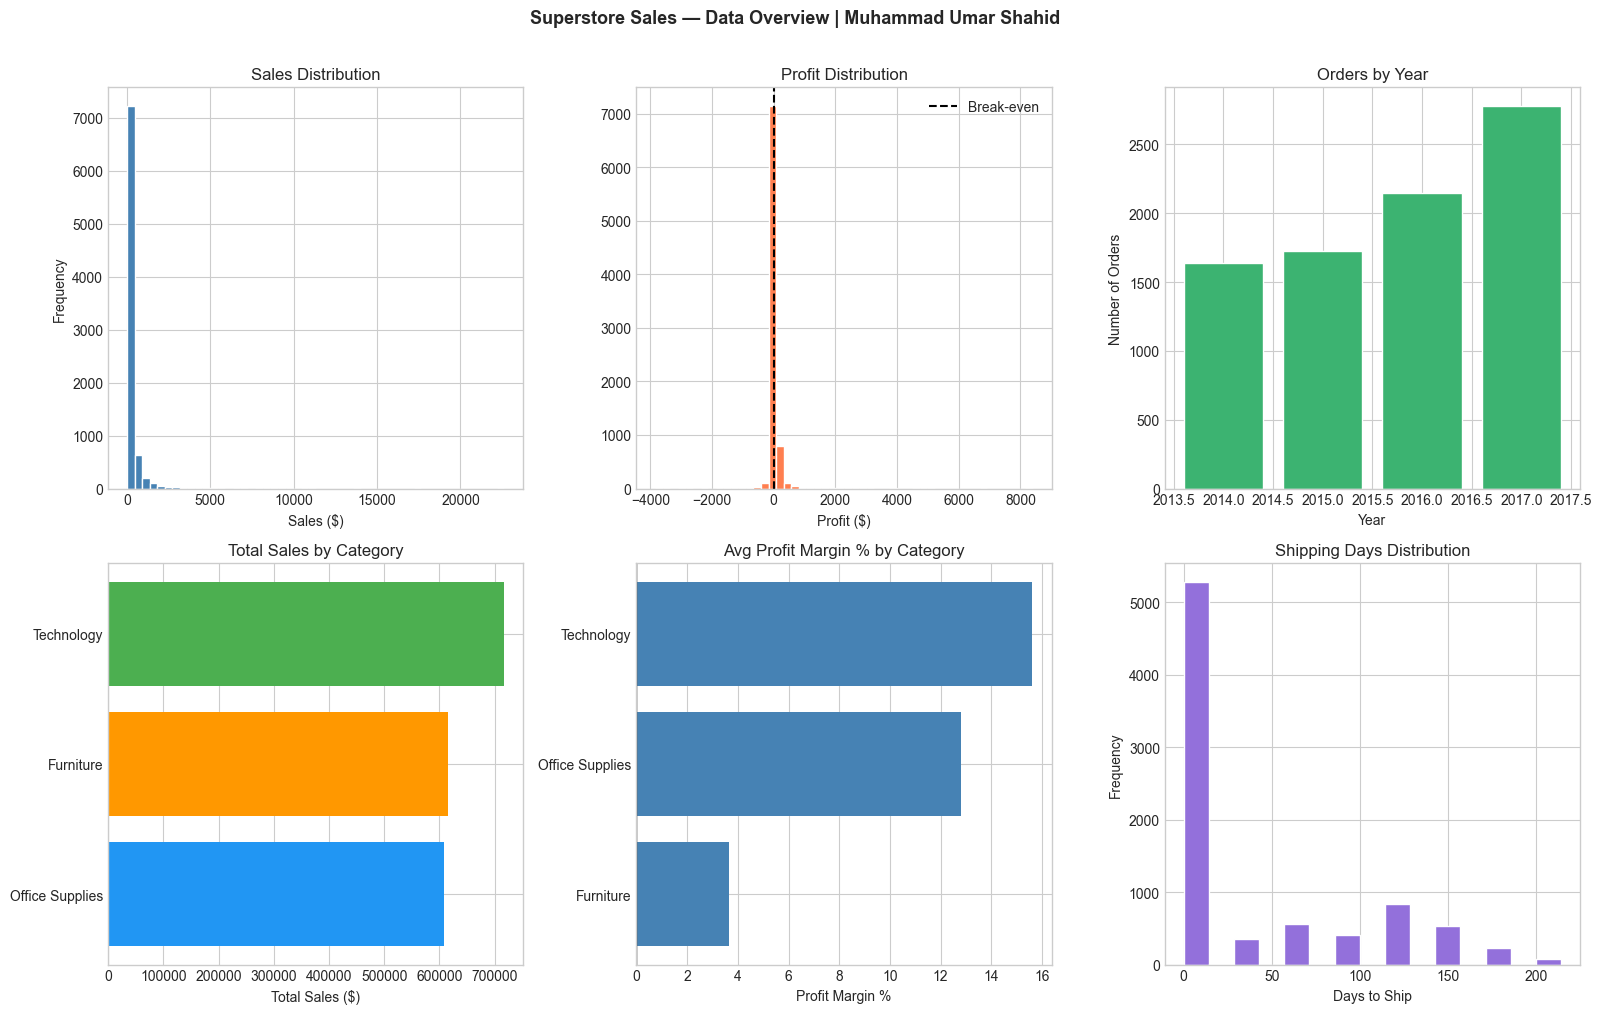

✅ Chart saved → reports/01_data_overview.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Superstore Sales — Data Overview | Muhammad Umar Shahid',
             fontsize=13, fontweight='bold', y=1.01)

# ── Chart 1: Sales Distribution ──────────────────────────────
# .hist() → frequency histogram showing how values are spread
# bins=50 → number of bars (more bins = more detail)
# edgecolor='white' → thin white lines between bars for clarity
axes[0,0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Sales Distribution')
axes[0,0].set_xlabel('Sales ($)')
axes[0,0].set_ylabel('Frequency')

# ── Chart 2: Profit Distribution ─────────────────────────────
# axvline() → draws a vertical line at x=0 (break-even line)
axes[0,1].hist(df['Profit'], bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Profit Distribution')
axes[0,1].set_xlabel('Profit ($)')
axes[0,1].axvline(0, color='black', linewidth=1.5,
                  linestyle='--', label='Break-even')
axes[0,1].legend()

# ── Chart 3: Orders by Year ───────────────────────────────────
# .groupby() → splits data into groups by column value
# ['Order ID'].count() → counts rows in each group
year_counts = df.groupby('Order Year')['Order ID'].count()
axes[0,2].bar(year_counts.index, year_counts.values,
              color='mediumseagreen', edgecolor='white')
axes[0,2].set_title('Orders by Year')
axes[0,2].set_xlabel('Year')
axes[0,2].set_ylabel('Number of Orders')

# ── Chart 4: Sales by Category ────────────────────────────────
# .sum() → total sales per category
# .sort_values() → ascending order (smallest bar at top for barh)
cat_sales = df.groupby('Category')['Sales'].sum().sort_values()
axes[1,0].barh(cat_sales.index, cat_sales.values,
               color=['#2196F3','#FF9800','#4CAF50'])
axes[1,0].set_title('Total Sales by Category')
axes[1,0].set_xlabel('Total Sales ($)')

# ── Chart 5: Profit Margin by Category ───────────────────────
# .mean() → average profit margin per category
# Conditional color: red if negative margin, blue if positive
cat_margin = df.groupby('Category')['Profit Margin %'].mean().sort_values()
bar_colors = ['red' if x < 0 else 'steelblue' for x in cat_margin.values]
axes[1,1].barh(cat_margin.index, cat_margin.values, color=bar_colors)
axes[1,1].set_title('Avg Profit Margin % by Category')
axes[1,1].set_xlabel('Profit Margin %')
axes[1,1].axvline(0, color='black', linewidth=1)

# ── Chart 6: Shipping Days Distribution ──────────────────────
axes[1,2].hist(df['Ship Days'], bins=15,
               color='mediumpurple', edgecolor='white')
axes[1,2].set_title('Shipping Days Distribution')
axes[1,2].set_xlabel('Days to Ship')
axes[1,2].set_ylabel('Frequency')

plt.tight_layout()

# savefig() → saves chart as image file
# dpi=150   → resolution (150 = good quality for reports)
# bbox_inches='tight' → no whitespace cropping
plt.savefig('../reports/01_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/01_data_overview.png")

---
## ✅ Module 1 Complete — Summary

### What We Did
| Step | Action | Result |
|------|--------|--------|
| Load | Read raw CSV | 9,800 rows × 18 columns |
| Inspect | `.info()`, `.describe()`, `.head()` | Understood structure & types |
| Missing Values | IQR + fillna | No missing values found |
| Data Types | `pd.to_datetime()`, `pd.to_numeric()` | Dates & numbers fixed |
| Duplicates | `.drop_duplicates()` | Checked & handled |
| Feature Engineering | `.dt`, `pd.cut()`, `pd.qcut()`, `.apply()` | 15+ new columns created |
| Outliers | IQR method | Detected & flagged (kept) |
| Save | `.to_csv()` | Clean file ready for pipeline |

### Files Produced
- `data/processed/superstore_clean.csv` → clean dataset for all downstream tools
- `reports/01_data_overview.png` → diagnostic chart

### Next Notebook
**`02_eda.ipynb`** → Exploratory Data Analysis with 15+ professional charts  
covering sales trends, customer behavior, product performance & geographic analysis
---